# STEP 3 · 基线错配 M₀ 与三场景 S1/S2/S3

量化现有充电站对车队的错配，并比较“只增/只减/等量调配”三类动作。

In [13]:
import os, sys, time, importlib
sys.path.insert(0, os.getcwd())          # STEP_0 已在本目录生成 cso_config.py / cso_engine.py
# 数据默认在“本 Code 目录的上一级”(项目根, 含 parquet 与 station csv)。如不同请改下一行或设环境变量 CSO_DATA：
# os.environ['CSO_DATA'] = r'D:/Desktop/香港大学/20260521 根据网约车轨迹优化充电站'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans'],
    'axes.unicode_minus': False,
})
import cso_config as C, cso_engine as E
importlib.reload(C); importlib.reload(E)
print('当前城市:', C.city()['label'], '| 数据:', C.city()['raw_path'].name, '| 缓存:', C.CACHE)

当前城市: 广州 Guangzhou | 数据: Taxi_2019_10_14_admin_4401.parquet | 缓存: D:\Desktop\香港大学\20260521 根据网约车轨迹优化充电站\Code\_cache


In [14]:
if not C.cache_file('segments').exists() or not C.cache_file('stations').exists():
    print('未发现缓存，开始预计算 ...'); print(E.precompute_segments())
else:
    print('已发现缓存，跳过预计算')
DRAWS = C.N_ENSEMBLE
D_mc = E.monte_carlo_demand_surface(draws=DRAWS)
D_naive = E.naive_demand_surface()
D = E.align_demand_surfaces(D_mc, D_naive)
st = E.load_stations()
slon = st['lon'].astype(float); slat = st['lat'].astype(float); nF = len(slon)
lc, ac, w_exp, w_naive = D['lon_c'], D['lat_c'], D['w_exp'], D['w_naive']
c = E.block_station_dist(lc, ac, slon, slat); min_c = c.min(axis=1)
print('需求格 %d | 站点 %d | 距离矩阵 %s' % (len(lc), nF, c.shape))


已发现缓存，跳过预计算
需求格 3309 | 站点 873 | 距离矩阵 (3309, 873)


## 3.1 基线 M₀
用当前配置的覆盖阈值 `C.C_BAR` 和抛锚惩罚 `C.P_DEAD` 计算错配指数。
M(F) = Σ_i w_i·min_j c_ij·1[min c ≤ C_BAR] + P_DEAD·Σ_i w_i·1[min c > C_BAR]

当前目标参数: C_BAR=100.000 km | P_DEAD=1000.0
期望需求 : M0=11359.3  平均M成本=3.650  最近站均距=3.650 km  抛锚率=0.0000
naive    : M0=4855.4  平均M成本=3.642  最近站均距=3.642 km  抛锚率=0.0000


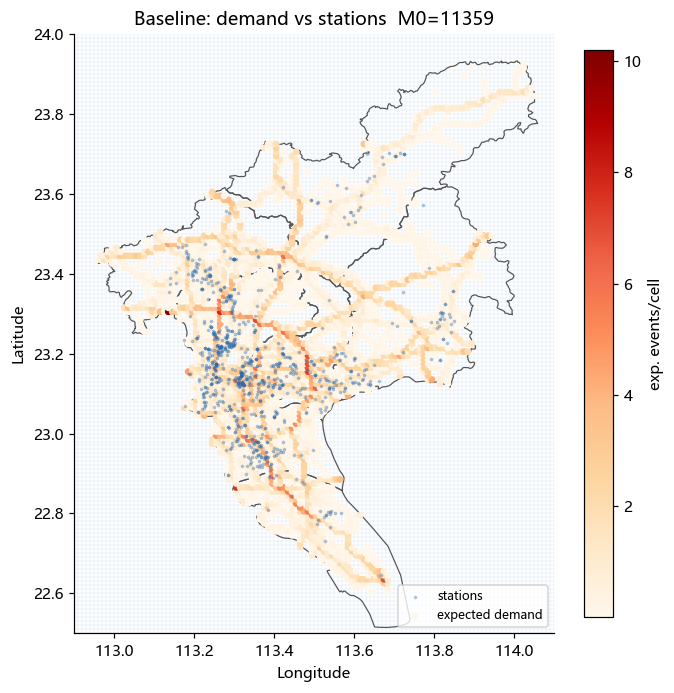

In [15]:
def stats(w):
    M0 = E.compute_M(w, min_c, c_bar=C.C_BAR, p_dead=C.P_DEAD)
    dead_rate = float(((min_c > C.C_BAR) * w).sum() / max(w.sum(), 1e-12)) 
    mean_cost = M0 / max(w.sum(), 1e-12)
    mean_nearest = float((w * min_c).sum() / max(w.sum(), 1e-12))
    return M0, mean_cost, dead_rate, mean_nearest

Me,me,de,ne = stats(w_exp); Mn,mn,dn,nn = stats(w_naive)
print('当前目标参数: C_BAR=%.3f km | P_DEAD=%.1f' % (C.C_BAR, C.P_DEAD))
print('期望需求 : M0=%.1f  平均M成本=%.3f  最近站均距=%.3f km  抛锚率=%.4f' % (Me,me,ne,de))
print('naive    : M0=%.1f  平均M成本=%.3f  最近站均距=%.3f km  抛锚率=%.4f' % (Mn,mn,nn,dn))

fig, ax = plt.subplots(figsize=(6.4,6.4)); m=w_exp>0
ax.scatter(slon,slat,s=2,c='#2b6cb0',alpha=0.4,marker='x',label='stations',zorder=5)
E.draw_city_context(ax=ax, show_admin=True, show_grid=True, grid_alpha=0.20, grid_linewidth=0.25)
s=ax.scatter(lc[m],ac[m],c=w_exp[m],cmap='OrRd',s=12,label='expected demand',zorder=4); plt.colorbar(s,ax=ax,label='exp. events/cell',fraction=0.046)
ax.set_title('Baseline: demand vs stations  M0=%.0f'%Me); ax.legend(loc='lower right',fontsize=8); plt.tight_layout(); plt.show()

## 3.2 S1 只增：贪心新增
候选=需求最高的若干格；贪心新增，看 M/M₀ 递减。

,新增比例,新增站数,M/M0,降幅%
0,1%,9,0.7284,27.2
1,2%,18,0.6465,35.3
2,5%,44,0.5212,47.9
3,10%,88,0.4170,58.3


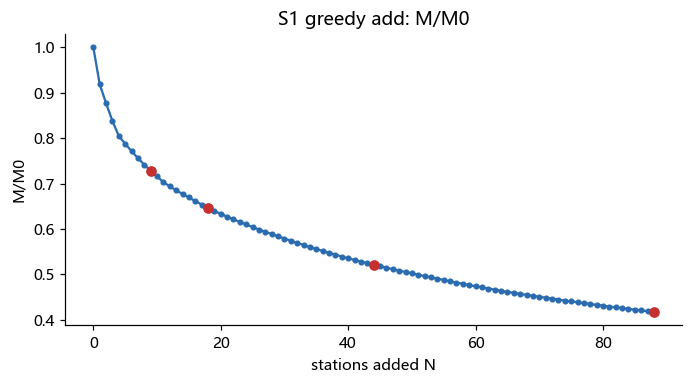

In [16]:
add_counts = C.add_station_counts(nF)
add_labels = [f'{int(frac*100)}%' for frac in C.ADD_STATION_FRACS]
cand = np.argsort(w_exp)[::-1][:min(C.CAND_CAP,len(w_exp))]
sel, hist = E.greedy_add(w_exp, min_c, lc[cand], ac[cand], lc, ac, max(add_counts)); ratio=np.array(hist)/Me
rat = lambda n: ratio[n] if len(ratio)>n else ratio[-1]

display(pd.DataFrame({'新增比例':add_labels,'新增站数':list(add_counts),'M/M0':[round(rat(n),4) for n in add_counts],'降幅%':[round(100*(1-rat(n)),1) for n in add_counts]}))
plt.figure(figsize=(6.4,3.6)); plt.plot(range(len(ratio)),ratio,'-o',ms=3,color='#2b6cb0')
plt.scatter(list(add_counts),[rat(n) for n in add_counts],color='#c53030',zorder=5)
plt.title('S1 greedy add: M/M0'); plt.xlabel('stations added N'); plt.ylabel('M/M0'); plt.tight_layout(); plt.show()

## 3.3.1 S2 只减
每个需求块只有一个最近站，故至多 |D| 个站“可能被需要”，**至少 |F|−|D| 个必然 Δ=0(与地理无关)**。真实聚集冗余Genuine：扣掉这个鸽笼结构下界之后，仍然由于需求空间分布集中、很多站从来不是最近有效站而产生的额外零边际部分。

【naive |D|=875】零边际站 61.9% | 鸽笼下界 max(|F|-|D|,0) 0.0% | 结构占比 约0% | 不同最近站 344
【现实集成更密 |D|=3309】鸽笼下界为 0.0%；剩余零边际来自空间聚集/最近站分配
前10%站承担边际价值 91.8% | 负载基尼 0.75


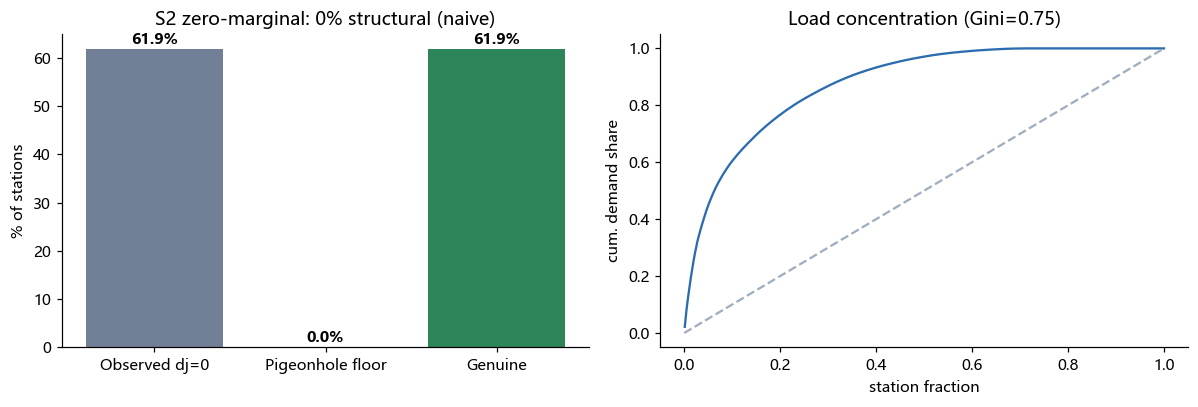

In [17]:
# 在 naive 单日需求非零的格子上做鸽笼分解：零边际站 = 数量结构下界 + 真实空间聚集冗余。
mN = w_naive>0
pig = E.pigeonhole_decomposition(c[mN], w_naive[mN])
print('【naive |D|=%d】零边际站 %.1f%% | 鸽笼下界 max(|F|-|D|,0) %.1f%% | 结构占比 约%.0f%% | 不同最近站 %d'
      % (pig['nD'],100*pig['zero_frac'],100*pig['floor_frac'],100*pig['mechanical_share'],pig['distinct_nearest']))

# 换成现实集成需求 w_exp 后，非零需求格通常更多；若 |D|>=|F|，鸽笼下界就是 0。
mE = w_exp>0; floorE = E.pigeonhole_decomposition(c[mE], w_exp[mE])['floor_frac']
print('【现实集成更密 |D|=%d】鸽笼下界为 %.1f%%；剩余零边际来自空间聚集/最近站分配' % (int(mE.sum()),100*floorE))

# 在现实集成需求上计算 S2 边际价值分布，并用前 10% 站点的累计边际价值衡量集中度。
delta,nearest,_,_ = E.marginal_delta(w_exp,c); load,gini,nl = E.event_load(w_exp,c)
s=np.sort(delta)[::-1]; cumv=np.cumsum(s)/s.sum(); top10=float(cumv[int(0.1*nF)])
print('前10%%站承担边际价值 %.1f%% | 负载基尼 %.2f' % (100*top10,gini))

# 可视化分解：Observed dj=0 是观测零边际比例，Pigeonhole floor 是结构必然部分，Genuine=两者差值。
obs=100*pig['zero_frac']; fl=100*pig['floor_frac']; gen=obs-fl
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
bars=ax[0].bar(['Observed dj=0','Pigeonhole floor','Genuine'],[obs,fl,gen],color=['#718096','#a0aec0','#2f855a'])
[ax[0].text(b.get_x()+b.get_width()/2,vv+1,'%.1f%%'%vv,ha='center',fontweight='bold') for b,vv in zip(bars,[obs,fl,gen])]
ax[0].set_ylabel('% of stations'); ax[0].set_title('S2 zero-marginal: %.0f%% structural (naive)'%(100*pig['mechanical_share']))
ld=np.sort(load)[::-1]; cl=np.cumsum(ld)/ld.sum(); ax[1].plot(np.arange(1,len(ld)+1)/len(ld),cl,color='#2b6cb0'); ax[1].plot([0,1],[0,1],'--',color='#a0aec0')
ax[1].set_title('Load concentration (Gini=%.2f)'%gini); ax[1].set_xlabel('station fraction'); ax[1].set_ylabel('cum. demand share'); plt.tight_layout(); plt.show()

### 3.3.1 S2 减站边际效应审查
进一步审查 S2 的减站后果：先按单站边际损失 ΔM 从小到大排序，再按这个初始 S2 顺序逐批移除低边际站，并在每个批次重新计算 M。如果按 S2 排名减少 N 个站，M/M0 会升到多少。

S2 审查：ΔM_j = M(移除站 j 后) - M(原始站集)；M0=11359.28
单站零/近零边际站 264 / 873 (30.2%)；正边际站 609；有最近分配负载的站 625；负载基尼 0.75
正边际站的 ΔM/M0 分位数：P50 0.003% | P90 0.071% | P99 1.331% | Max 8.015%
提示：下面的批量减站会重算 M；因此“单站 ΔM=0”的站一起移除时，M 仍可能上升。


,情景,减站数,减站比例%,M/M0,M增幅%
0,不减站,0,0.0000,1.0000,0.0000
2,减1%站,9,1.0309,1.0000,0.0000
5,减2%站,18,2.0619,1.0000,0.0000
10,减5%站,44,5.0401,1.0000,0.0049
19,减10%站,88,10.0802,1.0040,0.4034
50,移除全部初始零边际站,264,30.2405,1.0119,1.1882
51,零边际后再减1站,265,30.3551,1.0119,1.1882


,站点序号,经度,纬度,单站ΔM,单站ΔM/M0%,最近分配负载
754,754,113.667679,22.646113,910.416,8.015,63.29
661,661,113.422867,23.617419,396.836,3.494,58.00
743,743,113.537688,23.334708,263.906,2.323,66.92
700,700,113.786660,23.413823,181.061,1.594,57.89
241,241,113.723573,23.353179,172.666,1.520,43.92
802,802,113.721929,23.203174,171.453,1.509,37.03
260,260,113.445750,22.843135,151.645,1.335,51.31
353,353,113.457397,23.406080,145.739,1.283,42.77
198,198,113.527763,22.729781,140.613,1.238,42.19
789,789,113.519998,23.263103,130.186,1.146,32.73


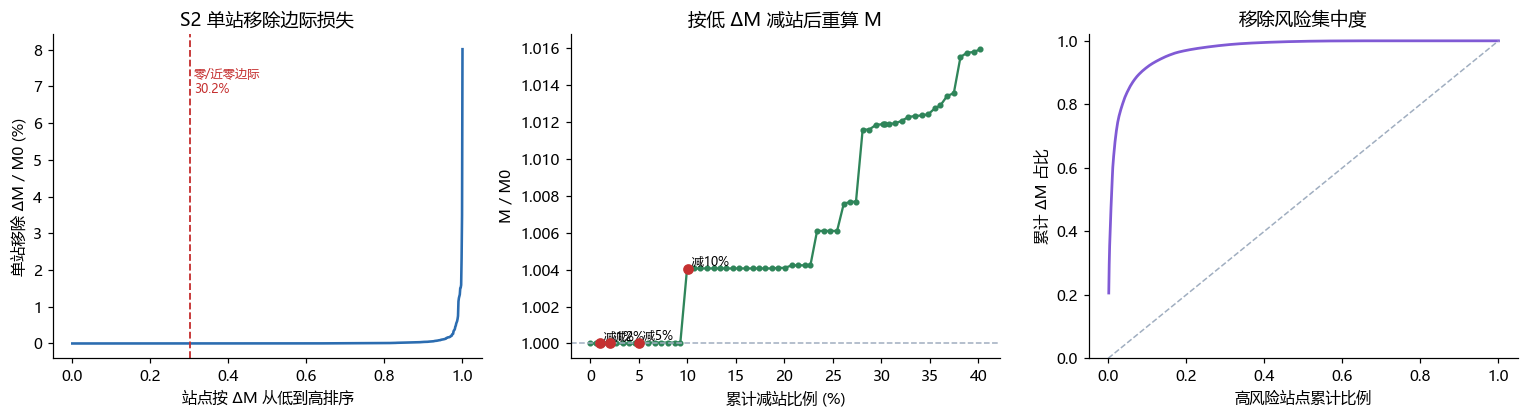

In [18]:
# S2 减站边际效应审查：单站 ΔM + 按初始低 ΔM 顺序逐批移除后重算 M/M0
M0_s2 = E.compute_M(w_exp, c.min(axis=1))
delta, nearest, first, second = E.marginal_delta(w_exp, c)
load, gini, n_loaded = E.event_load(w_exp, c)
order_low = np.argsort(delta)          # 初始 S2 顺序：先移除单站边际损失最小的站
eps = max(1e-9, 1e-10 * max(M0_s2, 1.0))
if M0_s2 <= eps:
    raise ValueError('M0 过小，不能稳定计算 M/M0；请先检查需求权重和距离矩阵。')
zero_n = int((delta <= eps).sum())
pos = delta[delta > eps]

print('S2 审查：ΔM_j = M(移除站 j 后) - M(原始站集)；M0=%.2f' % M0_s2)
print('单站零/近零边际站 %d / %d (%.1f%%)；正边际站 %d；有最近分配负载的站 %d；负载基尼 %.2f' %
      (zero_n, nF, 100*zero_n/nF, int((delta > eps).sum()), n_loaded, gini))
if len(pos):
    print('正边际站的 ΔM/M0 分位数：P50 %.3f%% | P90 %.3f%% | P99 %.3f%% | Max %.3f%%' %
          tuple(100*np.percentile(pos/M0_s2, [50, 90, 99, 100])))
print('提示：下面的批量减站会重算 M；因此“单站 ΔM=0”的站一起移除时，M 仍可能上升。')

# 批量减站：按初始低 ΔM 顺序移除，并在每个检查点重新计算最近站距离与 M。
# 这比简单累加 delta 更可靠，因为多个站同时移除后，最近/次近/第三近站关系会改变。
scenario_counts = np.array(C.add_station_counts(nF), dtype=int)
max_remove = min(nF - 1, max(int(0.30*nF), zero_n + int(0.10*nF), int(scenario_counts.max())))
grid_counts = np.linspace(0, max_remove, 61).astype(int)
remove_counts = np.unique(np.r_[grid_counts, scenario_counts, zero_n, min(nF - 1, zero_n + 1)])
remove_counts = remove_counts[(remove_counts >= 0) & (remove_counts < nF)]

M_removed = []
for k in remove_counts:
    if k == 0:
        mc = c.min(axis=1)
    else:
        keep = np.ones(nF, dtype=bool)
        keep[order_low[:k]] = False
        mc = c[:, keep].min(axis=1)
    M_removed.append(E.compute_M(w_exp, mc))
M_removed = np.asarray(M_removed)
curve = pd.DataFrame({
    'removed_n': remove_counts,
    'removed_pct': 100 * remove_counts / nF,
    'M': M_removed,
    'M_over_M0': M_removed / M0_s2,
    'M_increase_pct': 100 * (M_removed / M0_s2 - 1),
})

key_counts = np.unique(np.r_[0, scenario_counts, zero_n, min(nF - 1, zero_n + 1)])
summary = curve[curve['removed_n'].isin(key_counts)].copy()
summary['scenario'] = '检查点'
summary.loc[summary['removed_n'] == 0, 'scenario'] = '不减站'
if zero_n > 0:
    summary.loc[summary['removed_n'] == zero_n, 'scenario'] = '移除全部初始零边际站'
if zero_n + 1 < nF:
    summary.loc[summary['removed_n'] == min(nF - 1, zero_n + 1), 'scenario'] = '零边际后再减1站'
for frac, cnt in zip(C.ADD_STATION_FRACS, scenario_counts):
    summary.loc[summary['removed_n'] == cnt, 'scenario'] = '减%d%%站' % int(frac*100)
summary_show = summary.rename(columns={
    'scenario': '情景',
    'removed_n': '减站数',
    'removed_pct': '减站比例%',
    'M_over_M0': 'M/M0',
    'M_increase_pct': 'M增幅%',
})
display(summary_show[['情景', '减站数', '减站比例%', 'M/M0', 'M增幅%']].round(4))

risk = pd.DataFrame({
    'station': np.arange(nF),
    'lon': slon,
    'lat': slat,
    'delta_M': delta,
    'delta_M_over_M0_pct': 100 * delta / M0_s2,
    'assigned_load': load,
}).sort_values('delta_M', ascending=False).head(10)
risk_show = risk.rename(columns={
    'station': '站点序号',
    'lon': '经度',
    'lat': '纬度',
    'delta_M': '单站ΔM',
    'delta_M_over_M0_pct': '单站ΔM/M0%',
    'assigned_load': '最近分配负载',
})
display(risk_show.round({'经度': 6, '纬度': 6, '单站ΔM': 3, '单站ΔM/M0%': 3, '最近分配负载': 3}))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))
rank_frac = np.arange(1, nF + 1) / nF
d_low = delta[order_low]
ax[0].plot(rank_frac, 100*d_low/M0_s2, color='#2b6cb0', lw=1.7)
ax[0].axvline(zero_n/nF, color='#c53030', ls='--', lw=1.2)
y0, y1 = ax[0].get_ylim()
ax[0].text(min(zero_n/nF + 0.01, 0.95), y0 + 0.82*(y1-y0),
           '零/近零边际\n%.1f%%'%(100*zero_n/nF), color='#c53030', fontsize=8)
ax[0].set_title('S2 单站移除边际损失')
ax[0].set_xlabel('站点按 ΔM 从低到高排序')
ax[0].set_ylabel('单站移除 ΔM / M0 (%)')

ax[1].plot(curve['removed_pct'], curve['M_over_M0'], '-o', ms=3, color='#2f855a')
ax[1].axhline(1.0, color='#a0aec0', ls='--', lw=1)
for frac, cnt in zip(C.ADD_STATION_FRACS, scenario_counts):
    row = curve[curve['removed_n'] == cnt]
    if len(row):
        x = float(row['removed_pct'].iloc[0]); y = float(row['M_over_M0'].iloc[0])
        ax[1].scatter([x], [y], color='#c53030', zorder=5)
        ax[1].text(x, y, ' 减%d%%'%int(frac*100), fontsize=8, va='bottom')
ax[1].set_title('按低 ΔM 减站后重算 M')
ax[1].set_xlabel('累计减站比例 (%)')
ax[1].set_ylabel('M / M0')

pos_sum = delta.sum()
if pos_sum > eps:
    d_desc = np.sort(delta)[::-1]
    cum_delta = np.cumsum(d_desc) / pos_sum
    ax[2].plot(rank_frac, cum_delta, color='#805ad5', lw=1.8)
    ax[2].plot([0, 1], [0, 1], '--', color='#a0aec0', lw=1)
    ax[2].set_ylim(0, 1.02)
else:
    ax[2].text(0.5, 0.5, '所有 ΔM 近似为 0', ha='center', va='center')
ax[2].set_title('移除风险集中度')
ax[2].set_xlabel('高风险站点累计比例')
ax[2].set_ylabel('累计 ΔM 占比')
plt.tight_layout(); plt.show()

## 3.4 S3 等量调配
检验“重分配≈新建”。

swap-1% (N=9): M/M0=0.7284 (降 27.2%)
swap-2% (N=18): M/M0=0.6453 (降 35.5%)
swap-5% (N=44): M/M0=0.5191 (降 48.1%)
swap-10% (N=88): M/M0=0.4171 (降 58.3%)


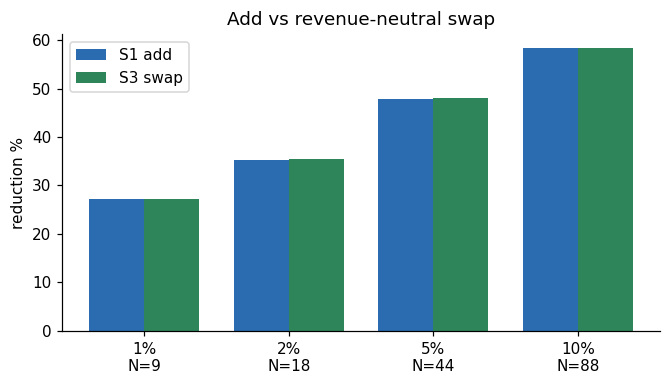

In [6]:
s3r={}
for label,N in zip(add_labels, add_counts):
    r=E.swap(w_exp,c,lc[cand],ac[cand],lc,ac,N); s3r[N]=r['M']/Me
    print('swap-%s (N=%d): M/M0=%.4f (降 %.1f%%)' % (label,N,s3r[N],100*(1-s3r[N])))
x=np.arange(len(add_counts)); ww=0.38
plt.figure(figsize=(6.2,3.6))
plt.bar(x-ww/2,[100*(1-rat(N)) for N in add_counts],ww,label='S1 add',color='#2b6cb0')
plt.bar(x+ww/2,[100*(1-s3r[N]) for N in add_counts],ww,label='S3 swap',color='#2f855a')
plt.xticks(x,[f'{lab}\nN={N}' for lab,N in zip(add_labels,add_counts)]); plt.ylabel('reduction %'); plt.title('Add vs revenue-neutral swap'); plt.legend(); plt.tight_layout(); plt.show()